### Análisis Exploratorio de Datos (EDA)

Equipo:17
Anuar Olmos López A01092551
Arturo Arellano Coyotl A01796088
Mireya Isabel Perez del Razo A01795608

Profesores
Dra. Grettel Barceló Alonso
Dr. Luis Eduardo Falcón Morales

Fecha: 31/01/2026

## Indice
1. Carga y Vista Inicial de Datos
2. Análisis de Valores Faltantes
3. Estadísticas Descriptivas
4. Análisis de Valores Atípicos
5. Cardinalidad de Variables Categóricas
6. Análisis de Distribuciones
7. Análisis de Correlaciones
8. Análisis Bivariado
9. Análisis de Desequilibrio de Clases
10. Combinaciones de Salida
11. Ambigüedad del Lenguaje
12. Conclusiones del EDA

1. Carga y Vista Inicial de Datos

En esta primera etapa se realiza la carga de la base de datos y una inspección inicial para entender su estructura general antes de aplicar análisis más profundos. El objetivo de esta sección es validar que el archivo se lea correctamente, confirmar el tamaño del dataset (número de registros y variables) y reconocer el tipo de información almacenada en cada columna. En este caso, el conjunto cuenta con 3,000 registros y 5 variables relacionadas con el control por voz de una silla de ruedas: dos variables de estado previo (estado_accion y estado_velocidad), una entrada de lenguaje natural (frase) y dos salidas esperadas del sistema (accion y velocidad). Esta verificación inicial permite asegurar coherencia en los datos y preparar el terreno para el análisis exploratorio, incluyendo la revisión de valores faltantes, distribución de categorías y patrones relevantes.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la base de datos
df = pd.read_csv("../data/raw/Base de Datos sucia v3.csv")
print(f"Tamaño del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Tamaño del dataset: 3000 filas, 5 columnas


,estado_accion,estado_velocidad,frase,accion,velocidad
0,apagado,detenida,por favor prender,prender,detenida
1,apagado,detenida,prendete rapido,prender,detenida
2,apagado,detenida,enciende,prender,detenida
3,apagado,detenida,activate!,prender,detenida
4,prendida,detenida,Hey Apaguete,apagar,detenida


In [82]:
print("Tipo de variables\n" )

df.info()

Tipo de variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   estado_accion     3000 non-null   object
 1   estado_velocidad  3000 non-null   object
 2   frase             3000 non-null   object
 3   accion            2708 non-null   object
 4   velocidad         2406 non-null   object
dtypes: object(5)
memory usage: 117.3+ KB


La lectura del archivo fue exitosa y la revisión inicial confirma que el dataset tiene un tamaño manejable (3,000 filas y 5 columnas) y que todas las variables son de tipo categórico/textual (object), lo cual es consistente con un problema de procesamiento de lenguaje natural con etiquetas. Además, se observa que estado_accion, estado_velocidad y frase están completos (sin valores faltantes), mientras que accion y velocidad presentan valores nulos en algunos registros. Esto sugiere que los faltantes podrían estar asociados a la lógica del dominio (por ejemplo, comandos que solo ajustan velocidad sin cambiar dirección, o comandos que solo cambian dirección sin especificar velocidad), más que a errores de captura. Con esta caracterización inicial, el dataset queda listo para el siguiente paso del EDA: cuantificar y explicar los faltantes, analizar distribución de clases y evaluar relaciones entre variables.

2. Análisis de Valores Faltantes

In [83]:
print("Valores faltantes:\n")
print(df.isnull().sum())

Valores faltantes:

estado_accion         0
estado_velocidad      0
frase                 0
accion              292
velocidad           594
dtype: int64


El análisis de valores faltantes muestra que estado_accion, estado_velocidad y frase están completamente pobladas, lo cual es positivo porque garantiza que siempre existe el contexto y el comando de entrada. Los faltantes se concentran únicamente en las variables de salida: accion (292 registros) y velocidad (594 registros), lo que sugiere un patrón coherente con la lógica del dominio. En particular, hay comandos donde el usuario únicamente ajusta la velocidad sin cambiar la acción, y otros donde define la acción sin especificar velocidad. Por ello, estos nulos deben interpretarse como valores “no aplica” más que como errores, y conviene tratarlos explícitamente en el preprocesamiento (por ejemplo, asignando una categoría como NA/no especificado) para mantener consistencia en el modelado posterior.

3. Estadísticas Descriptivas

In [84]:
df['num_palabras'] = df['frase'].str.split().str.len()
df['num_caracteres'] = df['frase'].str.len()
print("Estadísticas de las frases")
df[['num_palabras', 'num_caracteres']].describe()

Estadísticas de las frases


,num_palabras,num_caracteres
count,3000.000000,3000.000000
mean,4.304000,24.584333
std,1.607621,8.991913
min,1.000000,5.000000
25%,3.000000,18.000000
50%,4.000000,24.000000
75%,5.000000,30.000000
max,10.000000,57.000000


In [87]:
print(f"valores duplicados: {df.duplicated().sum()} \n")


valores duplicados: 96 



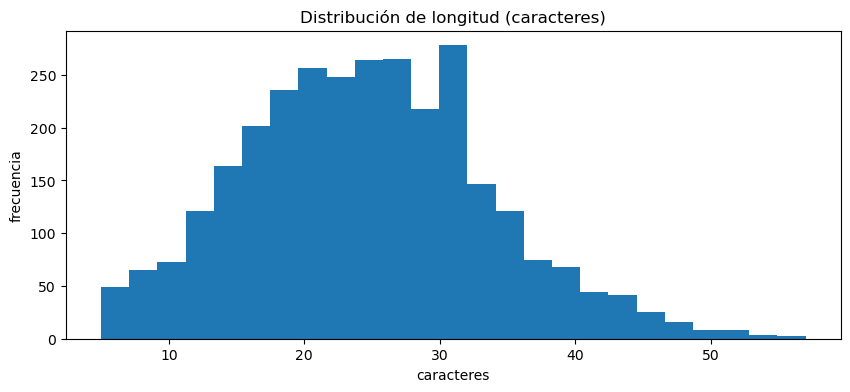

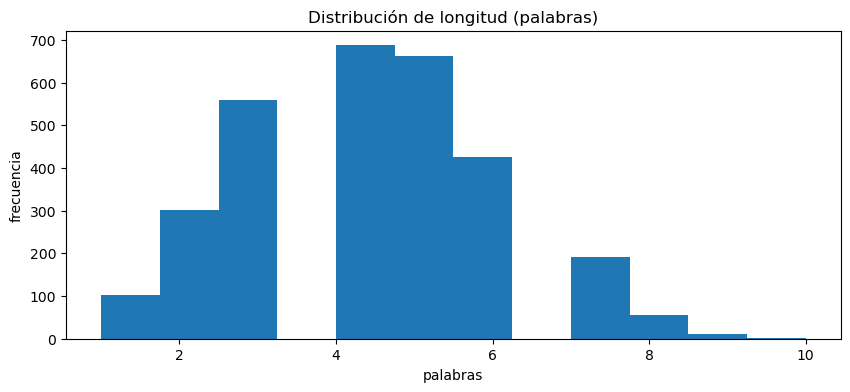

In [100]:
plt.figure(figsize=(10,4))
plt.hist(df["num_caracteres"], bins=25)
plt.title("Distribución de longitud (caracteres)")
plt.xlabel("caracteres")
plt.ylabel("frecuencia")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(df["num_palabras"], bins=12)
plt.title("Distribución de longitud (palabras)")
plt.xlabel("palabras")
plt.ylabel("frecuencia")
plt.show()

las estadísticas resumidas del conjunto de datos confirman que se trata de un dataset consistente con un problema de clasificación basado en comandos de voz, donde la variable principal de entrada es texto y las salidas son etiquetas categóricas. En esta sección se generaron métricas descriptivas enfocadas en la estructura y “tamaño” de las frases, lo cual es especialmente relevante en NLP, ya que la longitud del texto suele influir en la complejidad del preprocesamiento y en el desempeño de los modelos. Al cuantificar la longitud de cada comando, se observó que las frases son, en general, cortas y homogéneas, con un promedio de 4.30 palabras (mediana de 4) y un rango entre 1 y 10 palabras. En caracteres, las frases tienen una longitud promedio de 24.58 caracteres (mediana de 24), con un mínimo de 5 y un máximo de 57, lo que refuerza que el lenguaje usado corresponde a instrucciones breves y directas, adecuadas para interacción por voz.

Adicionalmente, se evaluó la presencia de registros repetidos y se identificaron 96 filas duplicadas, lo cual es un hallazgo importante para el análisis posterior: estos duplicados pueden representar repeticiones reales de ciertos comandos (frecuencia natural de uso) o redundancias que podrían inflar métricas si se entrena un modelo sin control. Finalmente, mediante los histogramas de longitud se visualizó la forma de la distribución tanto en caracteres como en palabras, observándose una concentración clara en rangos medios (aprox. 3–6 palabras y alrededor de 15–35 caracteres) con una cola hacia valores más altos, lo cual es normal en datos de texto donde algunas instrucciones incluyen detalles adicionales (“por favor”, “más rápido”, etc.). En conjunto, esta sección permite responder con fundamento que el dataset está compuesto por comandos principalmente breves, con variabilidad controlada, y deja preparados elementos clave para el EDA y el preprocesamiento: detección de outliers de texto, normalización, y decisiones sobre cómo manejar duplicados según el objetivo (conservar frecuencia real vs. deduplicar para evaluación).

4. Análisis de Valores Atípicos

In [ ]:
from collections import Counter

todas_palabras = " ".join(df['frase']).lower().split()
print(Counter(todas_palabras))

print(f"Palabras distintas usadas en el dataset: {len(Counter(todas_palabras))}")

Counter({'la': 782, 'a': 619, 'por': 560, 'velocidad': 526, 'favor': 516, 'de': 508, 'oye': 372, 'silla': 369, 'hey': 352, 'derecha': 339, 'izquierda': 331, 'ahorita': 326, 'normal': 325, 'en': 318, 'ya': 305, 'ahora': 288, 'inmediato': 278, 'atras': 258, 'para': 247, 'adelante': 243, 'mas': 239, 'gira': 218, 'hacia': 202, 'con': 174, 'rapido': 134, 'enfrente': 130, 've': 130, 'reversa': 118, 'dobla': 114, 'una': 104, 'voltea': 99, 'friega': 98, 'mueve': 92, 'este': 92, 'mete': 86, 'muevete': 86, 'momento': 78, 'echale': 70, 'despacio': 66, 'avanza': 66, 'corto': 66, 'lento': 64, 'dale': 58, 'pa': 57, 'frente': 57, 'manten': 55, 'apaga': 52, 'continua': 51, 'vamos': 50, 'modo': 49, 'reduce': 49, 'da': 48, 'calma': 48, 'al': 46, 'sigue': 43, "pa'": 42, 'aumenta': 41, 'subele': 41, 'acelera': 40, 'un': 40, 'derecho': 36, 'poco': 36, 'rueda': 36, 'apurate': 35, 'cuidado': 35, 'no': 35, 'tan': 35, 'tranqui': 33, 'desacelera': 29, 'suavecito': 29, 'retrocede': 29, 'enciendete': 28, 'baja': 

,num_caracteres,num_palabras
accion,,
izquierda,29.14,5.20
derecha,27.42,5.14
adelante,24.96,4.24
atras,23.93,4.14
adelante + izquierda,23.81,4.34
adelante + derecha,22.00,4.43
apagar,20.63,3.47
prender,20.45,3.43


<Figure size 1000x400 with 0 Axes>

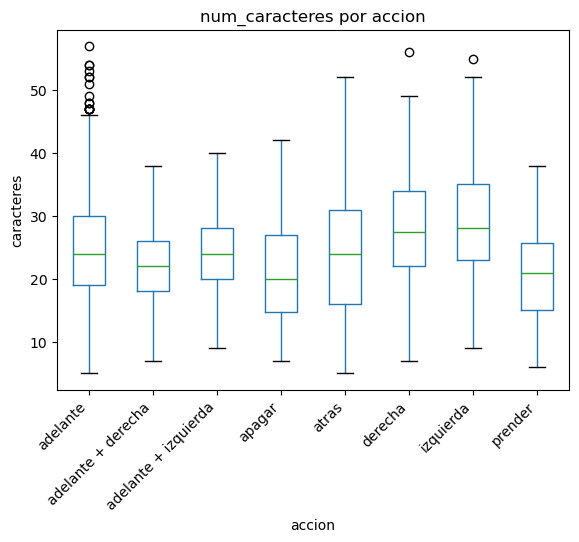

<Figure size 800x400 with 0 Axes>

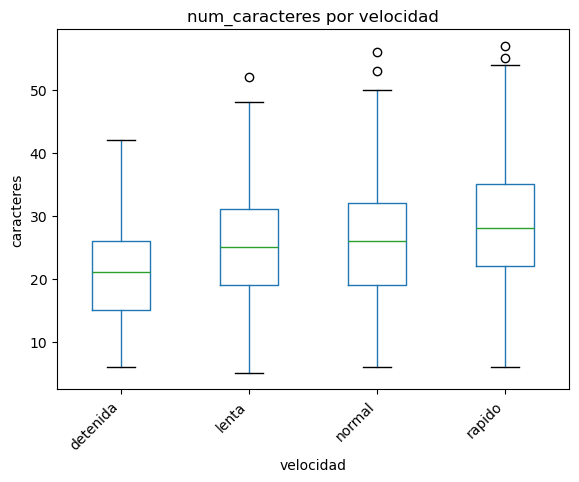

In [94]:

if "accion" in df.columns:
    display(df.groupby("accion")[["num_caracteres", "num_palabras"]].mean().round(2).sort_values("num_caracteres", ascending=False))
    plt.figure(figsize=(10,4))
    df.boxplot(column="num_caracteres", by="accion", grid=False)
    plt.title("num_caracteres por accion")
    plt.suptitle("")
    plt.xlabel("accion")
    plt.ylabel("caracteres")
    plt.xticks(rotation=45, ha="right")
    plt.show()
if "velocidad" in df.columns:
    plt.figure(figsize=(8,4))
    df.boxplot(column="num_caracteres", by="velocidad", grid=False)
    plt.title("num_caracteres por velocidad")
    plt.suptitle("")
    plt.xlabel("velocidad")
    plt.ylabel("caracteres")
    plt.xticks(rotation=45, ha="right")
    plt.show()

In [101]:
col_texto = "frase" if "frase" in df.columns else df.columns[0]

print("\nTop 10 frases más largas:")
display(df[[col_texto, "num_caracteres", "num_palabras"]].sort_values("num_caracteres", ascending=False).head(10))

print("\nTop 10 frases más cortas:")
display(df[[col_texto, "num_caracteres", "num_palabras"]].sort_values("num_caracteres", ascending=True).head(10))


Top 10 frases más largas:


,frase,num_caracteres,num_palabras
806,silla muevete para enfrente mete velocidad de ...,57,8
1269,silla gira para la derecha a velocidad normal ...,56,10
2427,hey ve al lado izquierdo con mas velocidad de ...,55,10
1019,Por Favor Dale Para Enfrente Con Mas Velocidad...,54,9
2518,POR FAVOR DALE PARA ENFRENTE CON MAS VELOCIDAD...,54,9
377,hey rueda hacia adelante a velocidad normal po...,53,9
1681,silla aumenta la velocidad de inmediato de inm...,53,8
164,silla llegale hacia adelante con mas velocidad...,52,8
2578,sillA llegale de revErsa con mas vELociDAd por...,52,9
937,silla aumenta la velocidad de inmediato de inm...,52,8



Top 10 frases más cortas:


,frase,num_caracteres,num_palabras
888,atras,5,1
2493,aTrAs,5,1
658,lenta,5,1
1096,atras,5,1
2414,lenta,5,1
2214,Lento,5,1
1868,Atras,5,1
1812,Lenta,5,1
950,LENTO,5,1
2567,Normal,6,1


3 ¿Hay valores atípicos en el conjunto de datos?

Si tomamos en cuenta la cantidad de caracteres y palabras en las oraciones se logran observar ciertos valores atipos, por ejemplo solo hay una oración con el mayor número de caracteres (57):  
"silla muevete para enfrente mete velocidad de inmediato??"

En cuanto a la cantidad de palabras también existen valores atipicos, ya que del conjunto solo dos oraciones tienen 10 palabras en total:
"hey ve al lado izquierdo con mas velocidad de inmediato"
silla gira para la derecha a velocidad normal por favor!

5. Cardinalidad de Variables Categóricas

Variables de categóricas de entrada

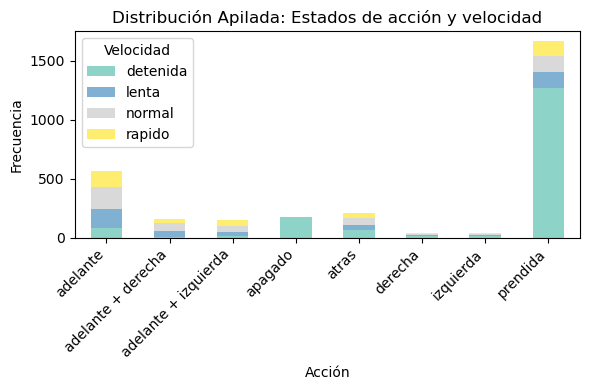

In [113]:
# 4. Stacked bar: Dirección y Velocidad
import matplotlib.pyplot as plt
import pandas as pd

# Crosstab
crosstab_counts = pd.crosstab(df['estado_accion'], df['estado_velocidad'])

# Plot
crosstab_counts.plot(
    kind='bar',
    stacked=True,
    colormap='Set3',
    figsize=(6, 4)
)

# Títulos y etiquetas
plt.title('Distribución Apilada: Estados de acción y velocidad')
plt.ylabel('Frecuencia')
plt.xlabel('Acción')

# Rotación de etiquetas
plt.xticks(rotation=45, ha='right')

# Leyenda
plt.legend(title='Velocidad')

# Ajuste de layout
plt.tight_layout()
plt.show()

Variables categóricas de salida

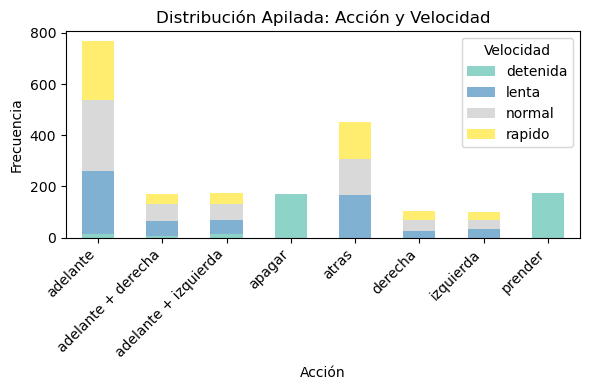

In [114]:
# 4. Stacked bar: Dirección y Velocidad
import matplotlib.pyplot as plt
import pandas as pd

# Crosstab
crosstab_counts = pd.crosstab(df['accion'], df['velocidad'])

# Plot
crosstab_counts.plot(
    kind='bar',
    stacked=True,
    colormap='Set3',
    figsize=(6, 4)
)

# Títulos y etiquetas
plt.title('Distribución Apilada: Acción y Velocidad')
plt.ylabel('Frecuencia')
plt.xlabel('Acción')

# Rotación de etiquetas
plt.xticks(rotation=45, ha='right')

# Leyenda
plt.legend(title='Velocidad')

# Ajuste de layout
plt.tight_layout()
plt.show()

¿Cuál es la cardinalidad de las variables categóricas?
La cardinalidad de las variables categóricas de entrada y salida es baja.
En el caso de la variable categórica de entrada "estado_acción hay 8 clases, mientras que en la de "estado_velocidad" hay 4.
En el caso de las variables categóricas de salida el resultado es el mismo 8 y 4 para acción y velocidad, esto se debe a que las acciones y velocidades pasan a actualizar los estados de velocidad y acción respectivamente.


6. Análisis de Distribuciones

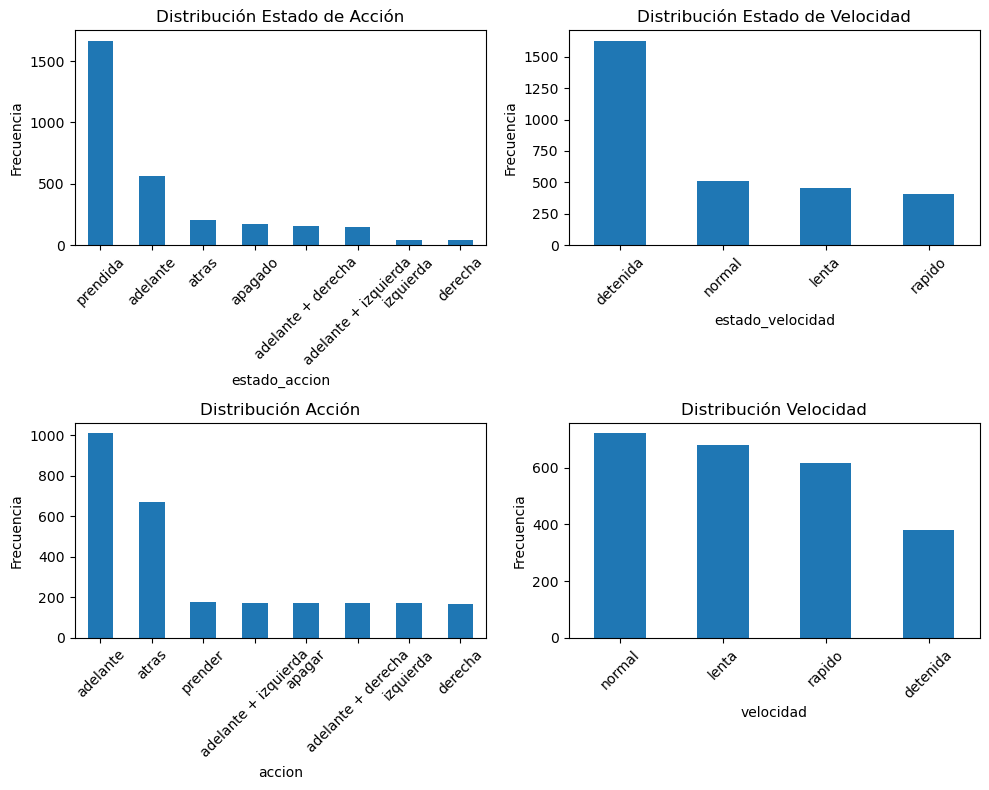

In [125]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1️⃣ Distribución de estado_accion
df['estado_accion'].value_counts().plot(
    kind='bar',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Distribución Estado de Acción')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2️⃣ Distribución de estado_velocidad
df['estado_velocidad'].value_counts().plot(
    kind='bar',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Distribución Estado de Velocidad')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3️⃣ Distribución de estado (ej. activo / detenido)
df['accion'].value_counts().plot(
    kind='bar',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Distribución Acción')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].tick_params(axis='x', rotation=45)

# 3️⃣ Distribución de estado (ej. activo / detenido)
df['velocidad'].value_counts().plot(
    kind='bar',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución Velocidad')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].tick_params(axis='x', rotation=45)



# Ajuste general
plt.tight_layout()
plt.show()


In [ ]:
5 ¿Existen distribuciones sesgadas en el conjunto de datos? ¿Necesitamos aplicar alguna transformación no lineal?
Agregar descripcion de si hay sesgo en los datos

7. Análisis de Correlaciones

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# 9) CLUSTERING (TF-IDF -> SVD -> KMEANS) + SILHOUETTE + VIS 2D
# ============================================================

# 9.1) TF-IDF Vectorization
tfidf_sim = TfidfVectorizer(ngram_range=(1, 2), min_df=2, stop_words=None)
X_tfidf = tfidf_sim.fit_transform(df["frase"])

# Reducir dimensionalidad para clustering estable
n_comp = min(80, X_tfidf.shape[1]-1) if X_tfidf.shape[1] > 2 else 2
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_red = svd.fit_transform(X_tfidf)
# Buscar k con silhouette
k_range = list(range(2, 13))
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_red)
    sil = silhouette_score(X_red, labels)
    sil_scores.append(sil)
best_k = k_range[int(np.argmax(sil_scores))]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df["cluster_kmeans"] = kmeans.fit_predict(X_red)

print("\nDistribución de clusters:")
display(df["cluster_kmeans"].value_counts().to_frame("count"))
# ¿Qué significa cada cluster? -> top términos del cluster y ejemplos representativos
feature_names = np.array(tfidf_sim.get_feature_names_out())

def top_terms_cluster(cluster_id, topn=12):
    center = kmeans.cluster_centers_[cluster_id]
    idx = center.argsort()[::-1][:topn]
    return feature_names[idx]

print("\nTop términos por cluster:")
for c in sorted(df["cluster_kmeans"].unique()):
    print(f"Cluster {c}: {', '.join(top_terms_cluster(c, topn=12))}")

print("\nComposición de clusters vs direccion:")
display(pd.crosstab(df["cluster_kmeans"], df["direccion"], normalize="index").round(3))

print("\nComposición de clusters vs velocidad (incluye NaN):")
display(pd.crosstab(df["cluster_kmeans"], df["velocidad"], dropna=False, normalize="index").round(3))

# Ejemplos representativos (frases más cercanas al centro del cluster)
# Distancia aproximada al centro usando el espacio reducido
centers = kmeans.cluster_centers_
dist_to_center = np.linalg.norm(X_red - centers[df["cluster_kmeans"].values], axis=1)
df["dist_center"] = dist_to_center

print("\nEjemplos representativos por cluster (distancia mínima):")
for c in sorted(df["cluster_kmeans"].unique()):
    sub = df[df["cluster_kmeans"] == c].sort_values("dist_center").head(5)
    print(f"\nCluster {c} - ejemplos:")
    display(sub[["frase_norm","direccion","velocidad","estado_silla","dist_center"]])

KeyError: 'frase_norm'

In [127]:
df[df['accion'] == 'derecha']['frase'].head(30)

17                                  derecha de inmediato
18                                          silla rapido
39                                          A La Derecha
40                       voltea a la derecha con cuidado
70                                     Por FAVor derEcha
73                           silla pa' la derecha rapido
75                        oye mueve a la derecha ahorita
88                      voltea a la derecha de inmediato
104               muevete al lado derecho mete velocidad
105                hey manten velocidad normal en friega
108                          pa' lA derecHa suaVecito ya
130                                hey gira a la derecha
165                 silla para la derecha mete velocidad
180                            gira derecha de inmediato
193    POR FAVOR DOBLA PA' LA DERECHA A VELOCIDAD NORMAL
226                            a velocidad normal de una
259                     por favor pa' la dereChA ahoriTa
260                            

In [ ]:
Se tienen solo 24 oraciones de una sola palabra, que son comandos cortos como: frena, acelera, apaga, prende etc.



Palabras clave: izquierda, derecha, adelante, atras, velocidad, detener, claxon,
Modificadores: rapido, lento, normal, suavecito, tranqui, despacito
Palabras no relevantes: la, para, con, a, hacia, en de al
Hay palabras que se usan solo 1 vez como "seco" '''

Sinónimos
Avanzar hacia adelante: adelante, frente, enfrente, avanza, camina, ve, muevete, continua, dale, echale, arrancate
Girar: dobla, gira, tuerce, voltea
Ir más lento: lento, despacio,despacito, suavecito, tranque, calma, reduce, bajale, desacelera'''

Es poco el vovabulario usado para controlar la silla de ruedas es mínimo a pesar de que se están usando varios sinónimos. También es de destacar que muchas palabras de dicho vocabulario no son relevantes para el control de la silla de ruedas


numero de palabras usadas en el dataset


array([4, 7, 6, 3, 5, 1, 2, 8], dtype=int64)



¿Se identifican tendencias temporales? (En caso de que el conjunto incluya una dimensión de tiempo).
¿Hay correlación entre las variables dependientes e independientes?
¿Cómo se distribuyen los datos en función de diferentes categorías? (análisis bivariado)
¿Se deberían normalizar las imágenes para visualizarlas mejor?
¿Hay desequilibrio en las clases de la variable objetivo?

In [ ]:

from collections import Counter

todas_palabras = " ".join(df['frase']).lower().split()
print(Counter(todas_palabras))

print(f"Palabras distintas usadas en el dataset:{len(Counter(todas_palabras))}")

3.3 Palabras más frecuentes

Palabras más frecuentes 
Counter({'la': 492, 'velocidad': 280, 'para': 269, 'izquierda': 242, 'con': 238, 'a': 228, 'derecha': 224, 'hacia': 222, 'mas': 196, 'rapido': 168, 'en': 167, 'de': 164, 'al': 161, 'atras': 158, 'normal': 158, "pa'": 131, 'reversa': 119, 'derecho': 101, 'lado': 99, 'muevete': 97, 'frente': 96, 've': 91, 'adelante': 90, 'apurate': 90, 'da': 89, 'mete': 80, 'vuelta': 76, 'lento': 75, 'gira': 72, 'dobla': 72, 'despacio': 71, 'calma': 70, 'cuidado': 70, 'voltea': 65, 'enfrente': 65, 'rueda': 64, 'suavecito': 64, 'tranqui': 60, 'despacito': 57, 'izquierdo': 51, 'sigue': 49, 'tuerce': 47, 'continua': 46, 'ya': 42, 'arrancate': 40, 'echale': 40, 'una': 39, 'dale': 36, 'llegale': 36, 'ahorita': 36, 'corto': 33, 'friega': 32, 'regresate': 30, 'este': 25, 'momento': 25, 'claxon': 25, 'ahora': 25, 'inmediato': 25, 'ponte': 23, 'quieta': 22, 'parate': 14, 'el': 14, 'alto': 13, 'retrocede': 13, 'avanza': 13, 'quedate': 13, 'marcha': 13, 'hazte': 12, 'camina': 12, 'caliente'


Palabras clave: izquierda, derecha, adelante, atras, velocidad, detener, claxon,
Modificadores: rapido, lento, normal, suavecito, tranqui, despacito
Palabras no relevantes: la, para, con, a, hacia, en de al
Hay palabras que se usan solo 1 vez como "seco" '''

Sinónimos
Avanzar hacia adelante: adelante, frente, enfrente, avanza, camina, ve, muevete, continua, dale, echale, arrancate
Girar: dobla, gira, tuerce, voltea
Ir más lento: lento, despacio,despacito, suavecito, tranque, calma, reduce, bajale, desacelera'''

Es poco el vovabulario usado para controlar la silla de ruedas es mínimo a pesar de que se están usando varios sinónimos. También es de destacar que muchas palabras de dicho vocabulario no son relevantes para el control de la silla de ruedas

Variables de salida

<Axes: xlabel='direccion'>

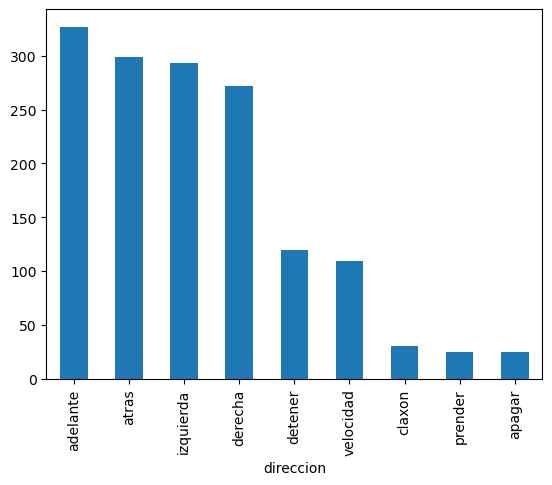

In [49]:
df['direccion'].value_counts().plot(kind='bar')

<Axes: xlabel='velocidad'>

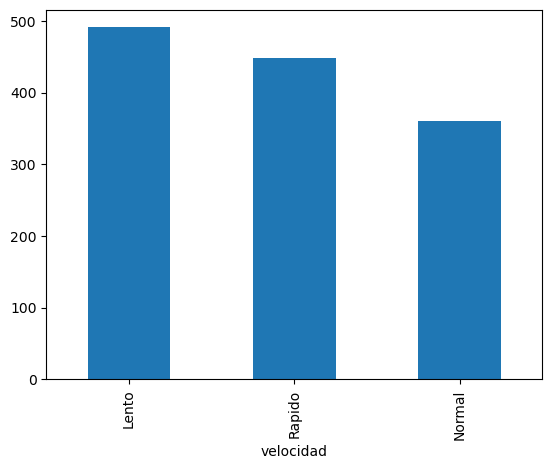

In [50]:
df['velocidad'].value_counts().plot(kind='bar')

<Axes: xlabel='estado_silla'>

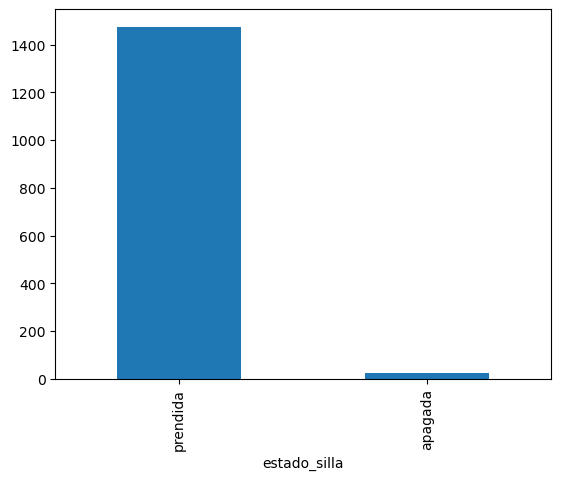

In [ ]:
df['estado_silla'].value_counts().plot(kind='bar')

Vemos que las en la variable de salida de velocidad, se tiene una distribuciones de clases uniforme, mientras que en la de dirección y de estado hay un desbalance.
En el caso de la variable dirección las clases dominantes son las de las direcciones principales (izquierda, derecha, adelante y atrás) y en el caso de estado, la predominantes es la clase prendida.
Esto puede comprometer el entrenamiento de los modelos.


Relación entre palabras y acciones

In [63]:
df[df['direccion'] == 'derecha']['frase'].head(30)


1         da vuelta hacia la derecha mas rapido
20                ve para la derecha mas rapido
24              muevete hacia la derecha normal
25                gira pa' la derecha con calma
28                   voltea a la derecha normal
31               tuerce al lado derecho apurate
37              da vuelta para la derecha lento
41                           ve al lado derecho
42        dobla hacia la derecha mete velocidad
44     dobla hacia la derecha con mas velocidad
49                    da vuelta para la derecha
59            ve a la derecha con mas velocidad
67               tuerce para la derecha tranqui
71      dobla pa' la derecha a velocidad normal
76               dobla a la derecha con cuidado
79                            ve pa' la derecha
80                 dobla a la derecha despacito
83                  gira a la derecha despacito
97                     pa' la derecha con calma
99                   da vuelta hacia la derecha
110              al lado derecho mete ve

Se tiene una relación al 100% de las frases con las acciones, esto se debe a que el dataset fue generado de manera sintética usando ChatGPT.

Combinaciones de salida

In [62]:
df.groupby(['estado_silla','direccion', 'velocidad']).size()

estado_silla  direccion  velocidad
prendida      adelante   Lento        117
                         Normal        97
                         Rapido       113
              atras      Lento        109
                         Normal        96
                         Rapido        94
              derecha    Lento         94
                         Normal        76
                         Rapido       102
              izquierda  Lento        125
                         Normal        72
                         Rapido        96
              velocidad  Lento         46
                         Normal        20
                         Rapido        43
dtype: int64